# Analysis of the "Databases" category

## Libraries and data set loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils as u

In [2]:
df_db = pd.read_parquet('datos/databases.parquet')
df_respondents = pd.read_parquet('datos/respondents.parquet')
df_db_metrics = pd.read_parquet('datos/databases_metrics.parquet')

## Top Databases

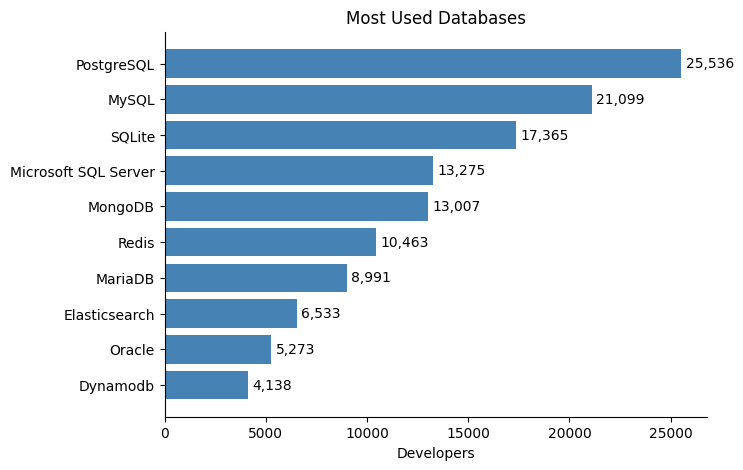

In [3]:
ax_db_have = u.bars_plot(df_db_metrics, 'HaveWorkedWith', 'Database', 'Most Used Databases')
plt.show()

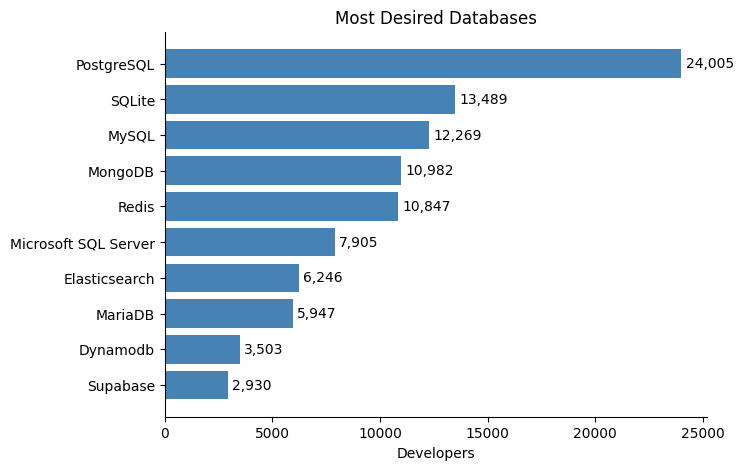

In [4]:
ax_db_want = u.bars_plot(df_db_metrics, 'WantToWorkWith', 'Database', 'Most Desired Databases')
plt.show()

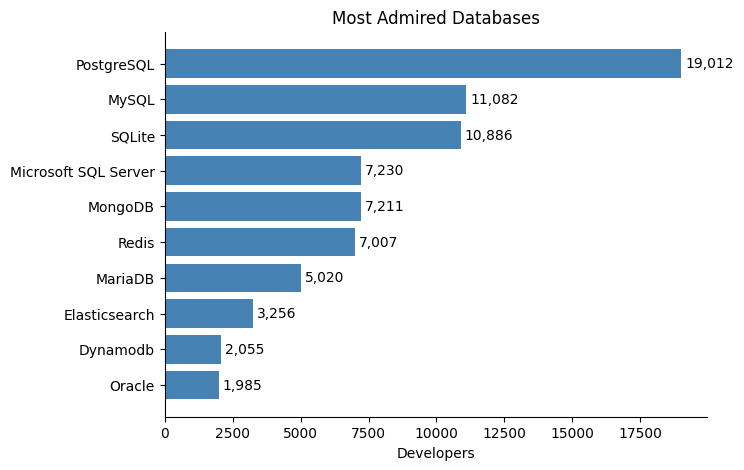

In [5]:
ax_db_adm = u.bars_plot(df_db_metrics, 'Admired', 'Database', 'Most Admired Databases')
plt.show()

- PostgreSQL se mantiene como la bases de datos mas usada, con intencion de aprender y admirada por los profesionales de TI este ultimo año.
- Tecnologías SQL se mantiene en el top 3 de bases de datos (PostgreSQL, MySQL, SQLite) mas usadas, admiradas y con intencion de aprender por parte de los profesionales de TI.
- Supabase adquiere cierto interes por parte de los porfesionales de TI, entrando al top 10 de las bases de datos que quieren aprender.

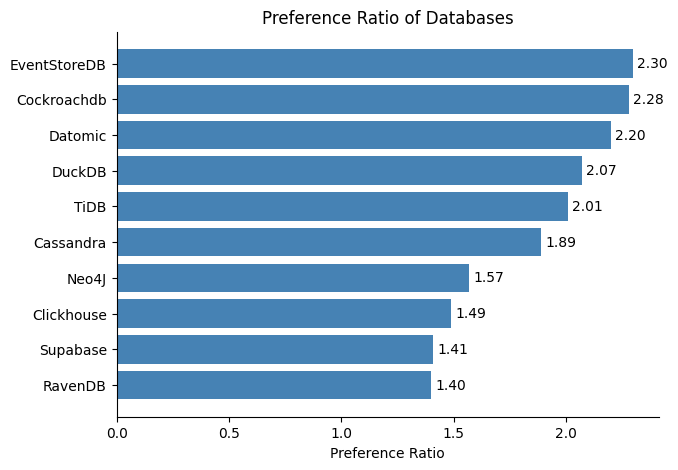

In [6]:
ax_prefer_ratio = u.bars_plot(df_db_metrics, 'PreferenceRate', 'Database', 'Preference Ratio of Databases', fmt = '{:.2f}', xlabel='Preference Ratio')
plt.show()

Bases de datos como EventStoreDB, CockroachDB y Datomic muestran los índices de preferencia más altos, lo que indica que muchos más desarrolladores quieren trabajar con ellas que aquellos que las utilizan actualmente. Esto sugiere un gran interés en estas tecnologías a pesar de su adopción relativamente menor.

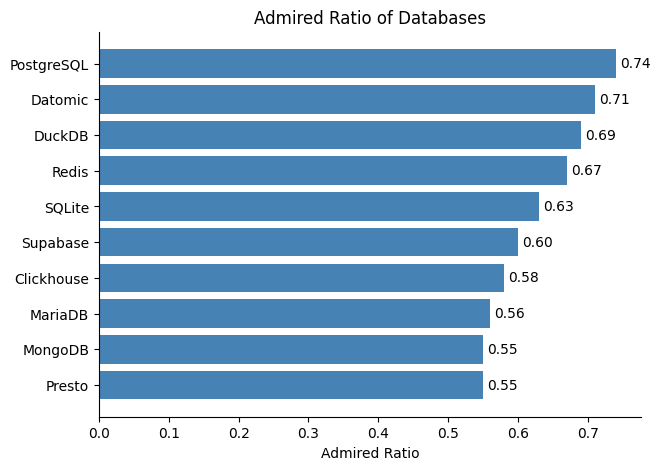

In [7]:
ax_adm_ratio = u.bars_plot(df_db_metrics, 'AdmiredRate', 'Database', 'Admired Ratio of Databases', fmt = '{:.2f}', xlabel='Admired Ratio')
plt.show()

PostgreSQL es la bases de datos mas admirados por los profesionales este año, siguiendolos las bases de datos como Datomic y DuckDB.

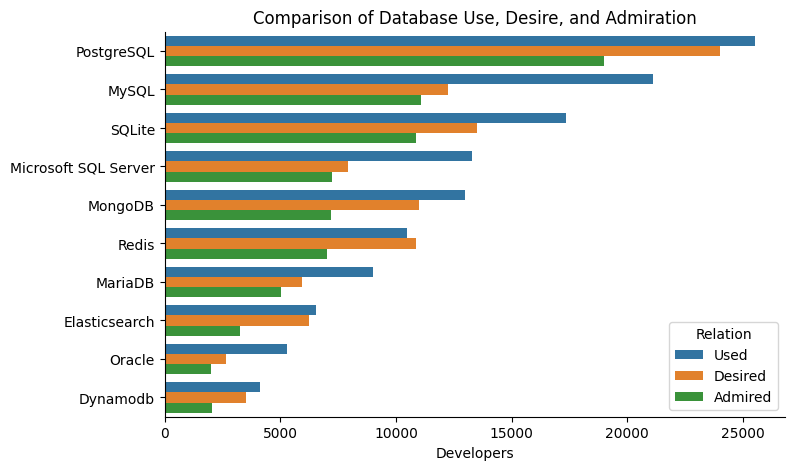

In [8]:
ax_comp = u.bar_comparative_plot(df_db_metrics, 'Database', 'Comparison of Database Use, Desire, and Admiration')
plt.show()

- Al observar el top 10 de bases de datos mas usados y compararlos con la que los profesionales quieren aprender a usar y admiran, hay una reduccion constante entre uso, preferencia y admiración, lo que indica que que gran parte de las bases de datos empleadas en este ultimo año es mas por necesidad que por preferencia de los porfesionales.  
- Redis tiene mayor proporcion de profesionales que quieren aprender a usarlo en comparación con profesionales que lo usan, lo que indica un interes en esta bases de datos que almacena datos en memoria.
- Elasticsearch tiene una proporcion casi igual entre profesionales que lo usan y lo quieren aprender a usar, indicando interes entre los profesionales. sin embargo, la proporcion de profesionales que lo admiran se reduce aproximadamente a la mitad, indicando que es una tecnologia que no agrada tanto a los profesionales pero es necesario para las empresas que la emplean.

In [9]:
x_median = df_db_metrics['HaveWorkedWith'].median()
df_plot = u.assign_quadrant(
    df_db_metrics, 
    'HaveWorkedWith', 
    'PreferenceRate', 
    x_median, 
    1, 
    'MarketQuadrant',
    'Growth',
    'Emerging',
    'Declining',
    'Mature'
)

growth   = df_plot[df_plot['MarketQuadrant'] == 'Growth'].nlargest(4, 'HaveWorkedWith')
emerging  = df_plot[df_plot['MarketQuadrant'] == 'Emerging'].nlargest(4, 'PreferenceRate')
mature    = df_plot[df_plot['MarketQuadrant'] == 'Mature'].nlargest(4, 'HaveWorkedWith')
declining = df_plot[df_plot['MarketQuadrant'] == 'Declining'].nsmallest(4, 'PreferenceRate')

label_df = pd.concat([growth, emerging, mature, declining])

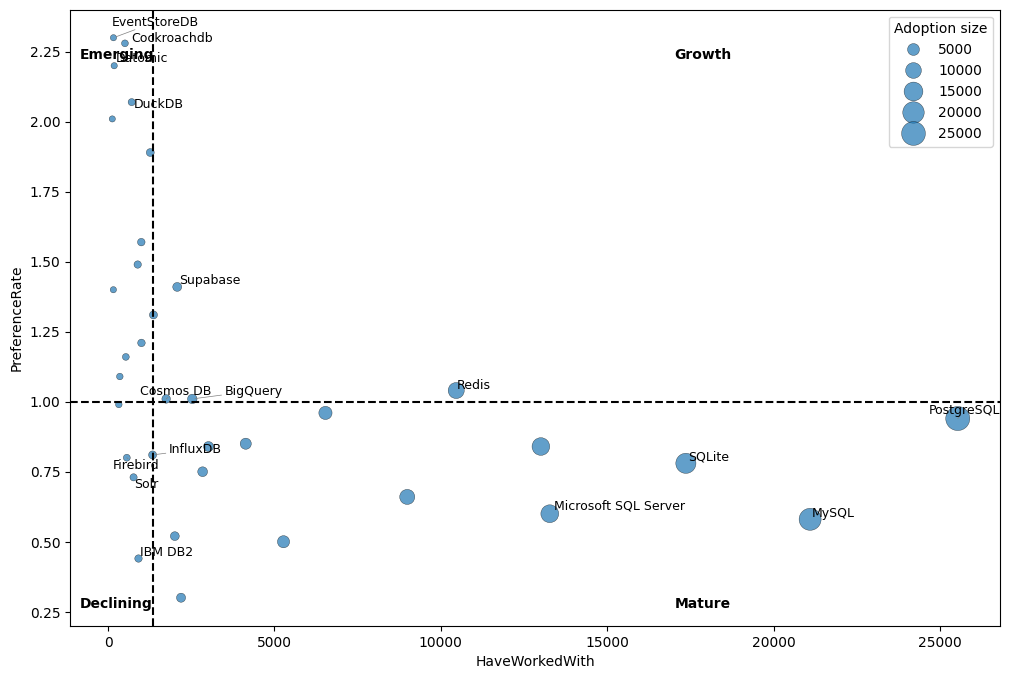

In [10]:
ax_have_prefer = u.quadrant_chart(df_db_metrics, 'HaveWorkedWith', 'PreferenceRate', x_median, 1, label_df, 'Growth', 'Emerging', 'Declining', 'Mature')
plt.show()

- Tecnologias SQL (PosgreSQL, MySQL, SQLite) mantienen una posición dominante debido a su amplia base, esto sugiere estabilidad y poca volatilidad en el corto plazo.
- Redis y Supabase presentan señales de crecimiento y alta fidelidad entre sus usuarios, lo que podría consolidarse a futuro.
- Tecnologias como EventStoreDB y DuckDB presentan tasas altas de intencion de adopción, aunque su base de usuarios aun es pequeña, representando oportunidades pero con mayor nivel de incertidumbre.
- Bases de datos como IBM DB2 y Firebird se usan mas para mantener sistemas existentes que por preferencia.

In [11]:
x_median = df_plot['PreferenceRate'].median()
y_median = df_plot['AdmiredRate'].median()

df_plot = u.assign_quadrant(
    df_plot,
    'PreferenceRate',
    'AdmiredRate',
    x_median,
    y_median,
    'PerceptionQuadrant',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

leaders = df_plot[df_plot['PerceptionQuadrant'] =='Leaders'].nlargest(4, 'AdmiredRate')
loved   = df_plot[df_plot['PerceptionQuadrant'] == 'Loved Niche'].nlargest(4, 'AdmiredRate')
trendy  = df_plot[df_plot['PerceptionQuadrant'] == 'Trendy'].nlargest(4, 'PreferenceRate')
weak    = df_plot[df_plot['PerceptionQuadrant'] == 'Weak'].nsmallest(4, 'AdmiredRate')

label_df = pd.concat([leaders, loved, trendy, weak])

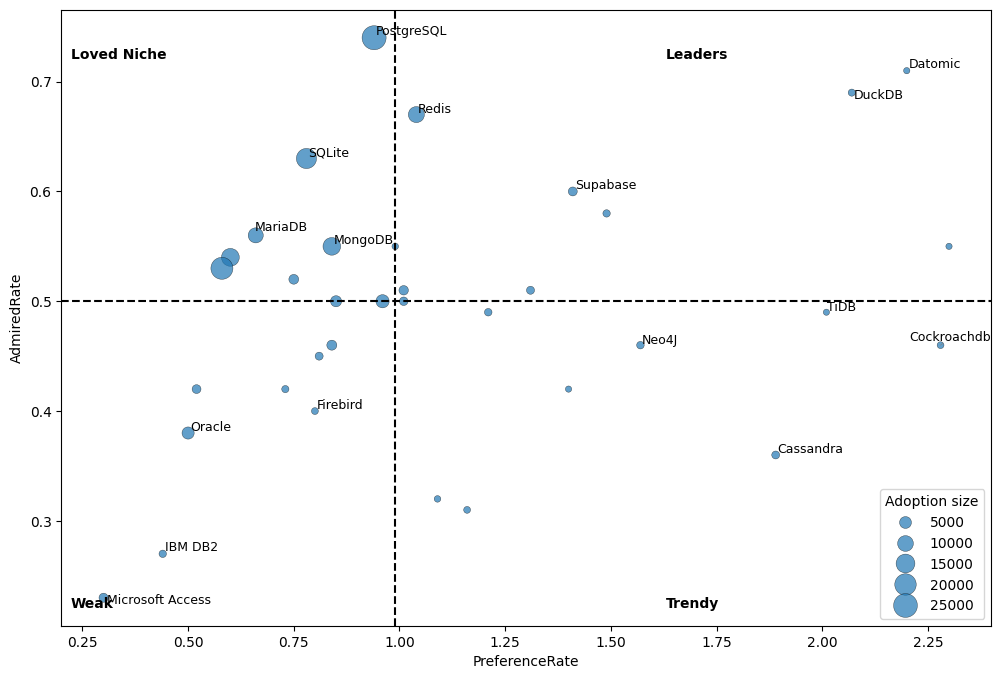

In [12]:
ax_prefer_adm = u.quadrant_chart(
    df_plot,
    'PreferenceRate',
    'AdmiredRate',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

- Un grupo reducido (Redis, Supabase, DuckDB, Datomic) combina alta satisfacción con fuerte intención de adopción, posicionándose como los mejor valorados del ecosistema.
- Tecnologías consolidadas como PostgreSQL, SQLite y MongoDB mantienen altos niveles de admiración, aunque con crecimiento más estable.
- Otras bases de datos muestran interés inicial sin consolidar alta lealtad (Trendy).
- Finalmente, un grupo presenta bajo dinamismo en percepción, con reducida intención futura y baja admiración (Microsoft Acces, IBM DB2).

In [13]:
comparison = (
    df_plot[
        ['MarketQuadrant', 'PerceptionQuadrant']
    ]
    .reset_index()
    .sort_values(['MarketQuadrant', 'PerceptionQuadrant'])
)

crosstab = pd.crosstab(
    df_plot['MarketQuadrant'],
    df_plot['PerceptionQuadrant']
)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_pct

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
MarketQuadrant,,,,
Declining,0.200000,0.000000,0.000000,0.800000
Emerging,0.333333,0.000000,0.666667,0.000000
Growth,1.000000,0.000000,0.000000,0.000000
Mature,0.000000,0.692308,0.000000,0.307692


- Todas las tecnologías clasificadas en el cuadrante de crecimiento (Growth) son percibidas por los desarrolladores como líderes.
- Aunque las tecnologías maduras tienen alta adopción en el mercado, la mayoría son percibidas como “Loved Niche”, lo que sugiere que son valoradas por quienes las usan, pero ya no generan el mismo entusiasmo o crecimiento.
- La mayoría de las tecnologías emergentes son percibidas como “Trendy”, lo que sugiere que los desarrolladores las ven como innovadoras o en tendencia, aunque todavía no están consolidadas.

En general, las percepciones de los desarrolladores se alinean bien con el posicionamiento en el mercado. Las tecnologías en el cuadrante de Crecimiento son ampliamente reconocidas como líderes, mientras que las tecnologías emergentes a menudo se perciben como modernas. Las tecnologías maduras tienden a ser valoradas por sus usuarios, pero están menos asociadas con la innovación, y las tecnologías en declive se perciben en gran medida como débiles.

In [14]:
market_score = {
    'Growth': 3,
    'Emerging': 2,
    'Mature': 1,
    'Declining': 0
}

perception_score = {
    'Leaders': 3,
    'Loved Niche': 2,
    'Trendy': 1,
    'Weak': 0
}

df_plot['MarketScore'] = df_plot['MarketQuadrant'].map(market_score)
df_plot['PerceptionScore'] = df_plot['PerceptionQuadrant'].map(perception_score)

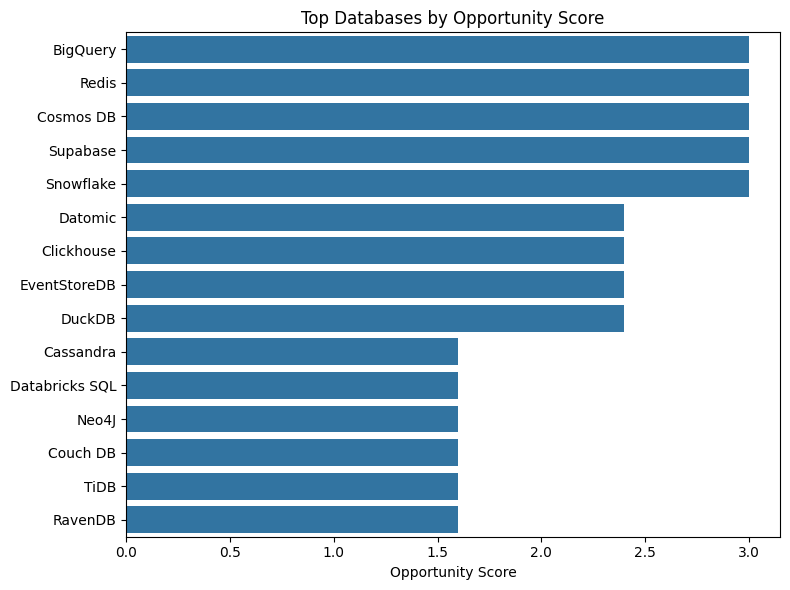

In [15]:
df_plot['OpportunityScore'] = (
    df_plot['MarketScore'] * 0.6 +
    df_plot['PerceptionScore'] * 0.4
)

ranking = (
    df_plot
    .sort_values('OpportunityScore', ascending=False).reset_index()
    [['Database', 'MarketQuadrant', 'PerceptionQuadrant', 'OpportunityScore']]
)

top = 15

df_rank = (
    df_plot
    .sort_values('OpportunityScore', ascending=False)
    .head(top)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_rank,
    x='OpportunityScore',
    y='Database'
)

plt.title('Top Databases by Opportunity Score')
plt.xlabel('Opportunity Score')
plt.ylabel('')

plt.tight_layout()
plt.show()

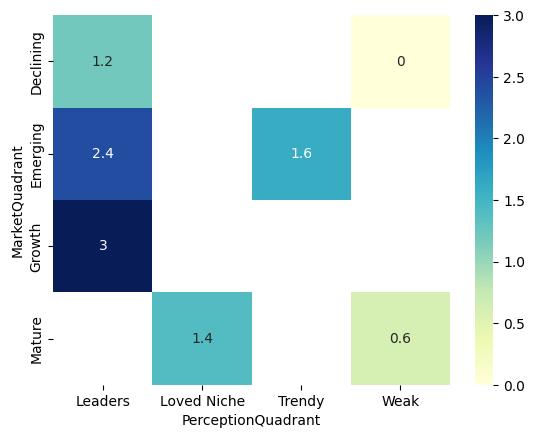

In [16]:
pivot = (
    df_plot
    .pivot_table(
        values="OpportunityScore",
        index="MarketQuadrant",
        columns="PerceptionQuadrant"
    )
)

sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.show()

- Las tecnologías emergentes que son percibidas como líderes presentan un alto Opportunity Score, lo que sugiere que estas herramientas tienen un fuerte potencial de crecimiento en el mercado.
- Las tecnologías en crecimiento que son percibidas como líderes presentan el Opportunity Score más alto, lo que indica una fuerte alineación entre adopción actual y entusiasmo de los desarrolladores.
- Las tecnologías maduras muestran Opportunity Scores relativamente bajos, lo que refleja mercados más estables y con menor potencial de crecimiento disruptivo.
- Las tecnologías en declive presentan oportunidades limitadas, ya que la percepción de los desarrolladores suele coincidir con su pérdida de relevancia en el mercado.

En general, las puntuaciones de oportunidad más altas aparecen cuando las tecnologías se perciben como líderes, pero aún no han alcanzado la madurez completa en el mercado. Esto sugiere que las mayores oportunidades residen en tecnologías que están consiguiendo un sólido apoyo de los desarrolladores y, al mismo tiempo, expandiendo su adopción en el mercado.

In [17]:
df_plot["AlignmentGap"] = (
    df_plot["PerceptionScore"] - df_plot["MarketScore"]
)

df_plot.sort_values("AlignmentGap", ascending=False)['AlignmentGap'].head(5)

Database
Presto                  3
Cloud Firestore         1
Clickhouse              1
Microsoft SQL Server    1
SQLite                  1
Name: AlignmentGap, dtype: int64

Presto presenta una percepción significativamente superior a su posición actual en el mercado, lo que indica una posible oportunidad de crecimiento impulsada por entusiasmo y admiración de la comunidad.

In [18]:
df_plot.sort_values("AlignmentGap")['AlignmentGap'].head(5)

Database
Cassandra                    -1
Couchbase                    -1
Couch DB                     -1
Cockroachdb                  -1
Firebase Realtime Database   -1
Name: AlignmentGap, dtype: int64

Cassandra y Couchbase muestran una posición de mercado sólida pero una percepción débil, lo que podría representar un riesgo de pérdida de atractivo futuro si no se renueva su ecosistema o propuesta de valor

In [19]:
df_db_exp = (
    df_db
    .merge(df_respondents[['ResponseId', 'YearsCodePro', 'Age_Group', 'RemoteWork_Clean', 'EdLevel_Group', 'Country']], on="ResponseId")
)
df_db_exp.head()

,ResponseId,Database,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country
0,2,Dynamodb,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
1,2,MongoDB,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
2,2,PostgreSQL,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
3,3,Firebase Realtime Database,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR
4,4,MongoDB,HaveWorkedWith,NaN,18-24,No especificado,No Formal Degree,CAN


In [20]:
df_analysis = df_db_exp.merge(
    df_plot.reset_index()[['Database', 'MarketQuadrant', 'PerceptionQuadrant', 
             'MarketScore', 'PerceptionScore', 'OpportunityScore', 'AlignmentGap']],
    on='Database',
    how='left'
)
df_analysis.head()

,ResponseId,Database,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country,MarketQuadrant,PerceptionQuadrant,MarketScore,PerceptionScore,OpportunityScore,AlignmentGap
0,2,Dynamodb,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
1,2,MongoDB,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
2,2,PostgreSQL,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
3,3,Firebase Realtime Database,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR,Mature,Weak,1,0,0.6,-1
4,4,MongoDB,HaveWorkedWith,NaN,18-24,No especificado,No Formal Degree,CAN,Mature,Loved Niche,1,2,1.4,1


In [21]:
df_analysis['MarketQuadrant'].isna().sum()

np.int64(0)

In [22]:
df_plot.reset_index()['Database'].nunique() == len(df_plot)

True

In [23]:
len(df_db_exp) == len(df_analysis)

True

In [24]:
(
    df_analysis[df_analysis["Relation"]=="HaveWorkedWith"]
    .groupby("MarketQuadrant")["YearsCodePro"]
    .mean()
    .sort_values()
)

MarketQuadrant
Mature       10.303578
Growth       10.478538
Emerging     11.048247
Declining    13.102708
Name: YearsCodePro, dtype: float64

Las bases de datos clasificadas como Declining presentan el mayor promedio de experiencia profesional (~13 años). Esto sugiere que su uso se concentra principalmente en desarrolladores senior que mantienen sistemas existentes.  

En contraste, las tecnologías Growth, Mature y Emerging muestran promedios cercanos a los 10-11 años de experiencia, lo que indica una adopción más equilibrada entre distintos niveles de seniority.

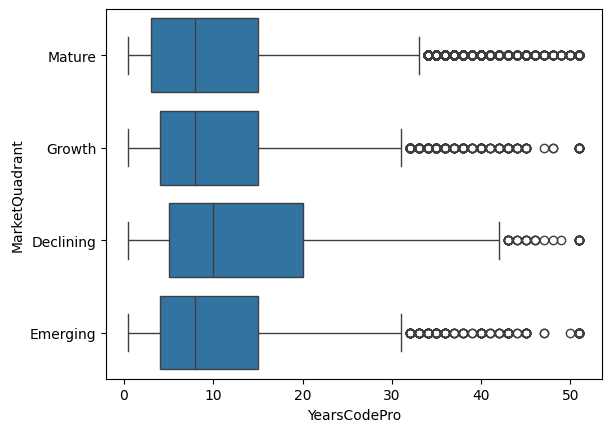

In [25]:
sns.boxplot(
    data=df_analysis[df_analysis['Relation'] == 'HaveWorkedWith'],
    x = 'YearsCodePro',
    y = 'MarketQuadrant'
)
plt.show()

Las tecnologías Declining concentran desarrolladores con más experiencia  
Las tecnologías Growth, Mature y Emerging tienen perfiles de experiencia muy similares  
La mayoría de desarrolladores en todas las categorías tiene menos de 15 años de experiencia  ]

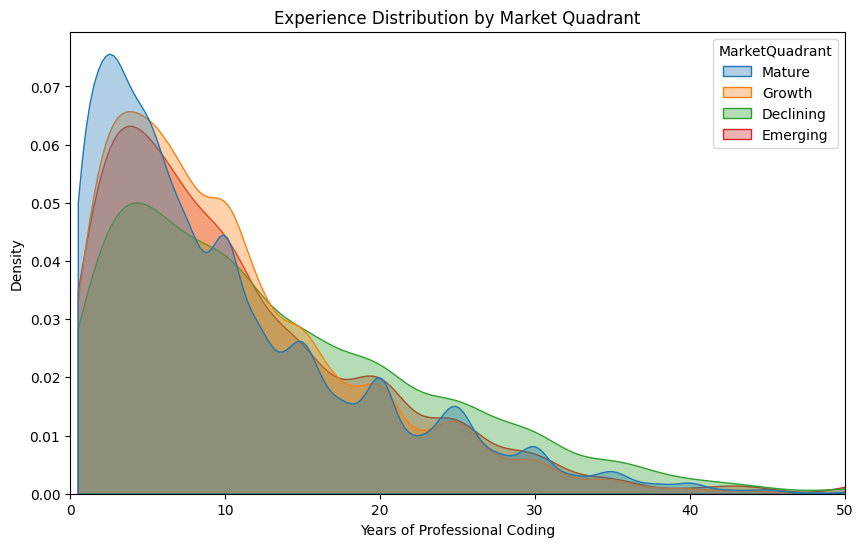

In [26]:
df_plot2 = df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_plot2,
    x = 'YearsCodePro',
    hue = 'MarketQuadrant',
    common_norm = False,
    fill = True,
    alpha = 0.35,
    cut = 0
)
plt.xlim(0,50)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Density')
plt.title('Experience Distribution by Market Quadrant')
plt.show()

- Las tecnologías emergentes y en crecimiento tienden a ser utilizadas principalmente por desarrolladores con menos años de experiencia, lo que sugiere que los profesionales más jóvenes adoptan con mayor rapidez nuevas herramientas y tecnologías.  
- Las tecnologías maduras presentan una adopción amplia en todos los niveles de experiencia, lo que refleja su consolidación y uso generalizado en la industria.  
- Las tecnologías en declive muestran una mayor proporción de desarrolladores con más años de experiencia, lo que sugiere que estas herramientas suelen estar asociadas con sistemas legacy o stacks tecnológicos más antiguos.  
- Independientemente del cuadrante de mercado, la mayor concentración de desarrolladores se encuentra en los primeros 10 años de experiencia profesional. 

En general, las tecnologías emergentes y en crecimiento tienden a atraer desarrolladores con menos años de experiencia, mientras que las tecnologías en declive muestran una participación relativamente mayor de desarrolladores más experimentados. Las tecnologías maduras, por otro lado, se utilizan en todos los niveles de experiencia, lo que refleja su estabilidad y adopción generalizada en la industria.

In [27]:
pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
Age_Group,,,,
18-24,0.131775,0.747812,0.038331,0.082082
25-34,0.167557,0.718594,0.040049,0.073800
35-44,0.170466,0.702046,0.042110,0.085378
45-54,0.138790,0.706530,0.043324,0.111355
55-64,0.100499,0.728698,0.033577,0.137226
65+,0.077922,0.712577,0.044087,0.165414
Under 18,0.116905,0.770395,0.032560,0.080139
Unknown,0.109403,0.734177,0.028933,0.127486


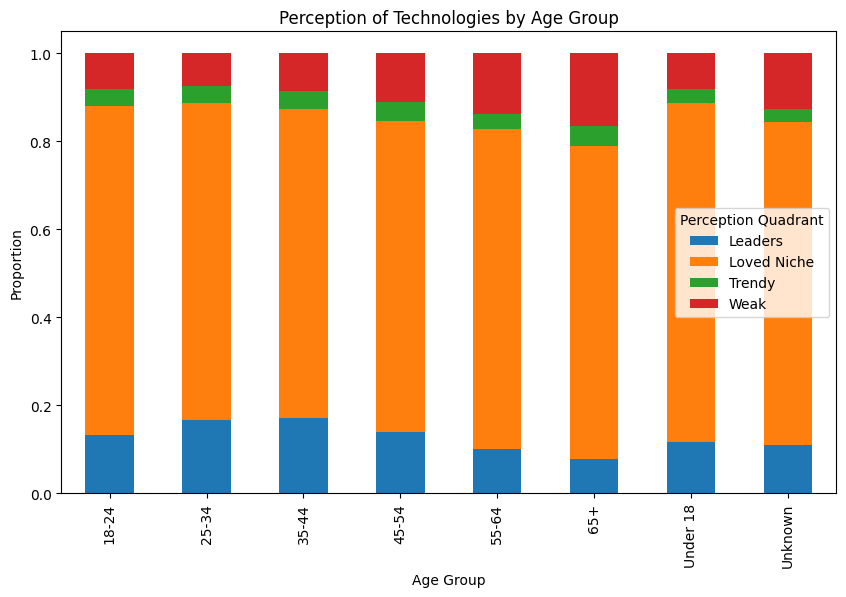

In [28]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Perception of Technologies by Age Group')
plt.legend(title = 'Perception Quadrant')
plt.show()

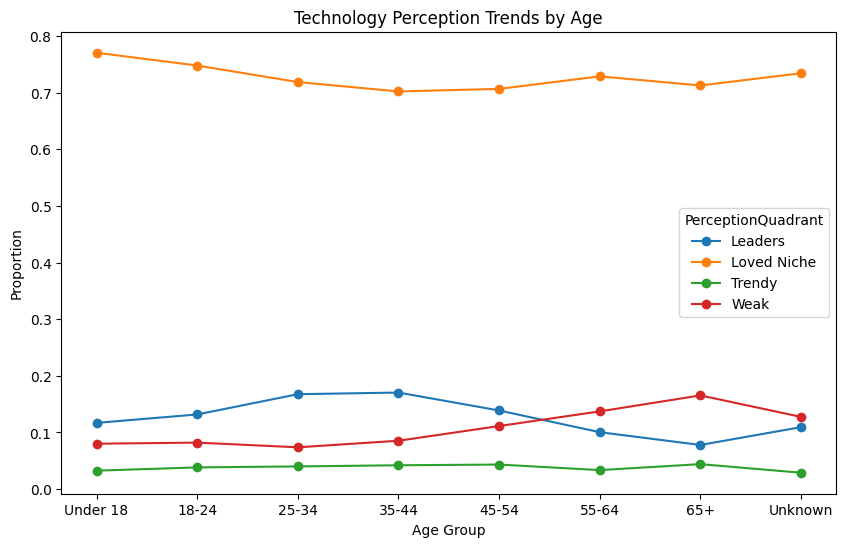

In [29]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

ct.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Technology Perception Trends by Age')
plt.show()

- En todos los grupos de edad, la mayoría de las tecnologías se perciben como "Loved Niche", lo que sugiere que muchas herramientas son apreciadas por sus usuarios pero su adopción generalizada es relativamente limitada.
- La proporción de tecnologías percibidas como líderes es mayor entre desarrolladores de 25–44 años, lo que puede reflejar su participación activa en la adopción y evaluación de pilas de tecnología modernas.
- La percepción de las tecnologías como débiles aumenta con la edad, lo que indica que los desarrolladores más experimentados pueden evaluar las tecnologías de manera más crítica basándose en la experiencia a largo plazo en la industria.
- La categoría "Trendy" se mantiene consistentemente baja en todos los grupos de edad, lo que sugiere que pocas tecnologías son vistas como tendencias de corta duración dentro del ecosistema de desarrolladores.

En general, la percepción de la tecnología se mantiene relativamente constante en todos los grupos de edad, con el "Nicho de interés" dominando en todos los segmentos. Sin embargo, los desarrolladores más jóvenes tienden a percibir más tecnologías como líderes, mientras que los desarrolladores de mayor edad muestran una mayor tendencia a clasificarlas como débiles.

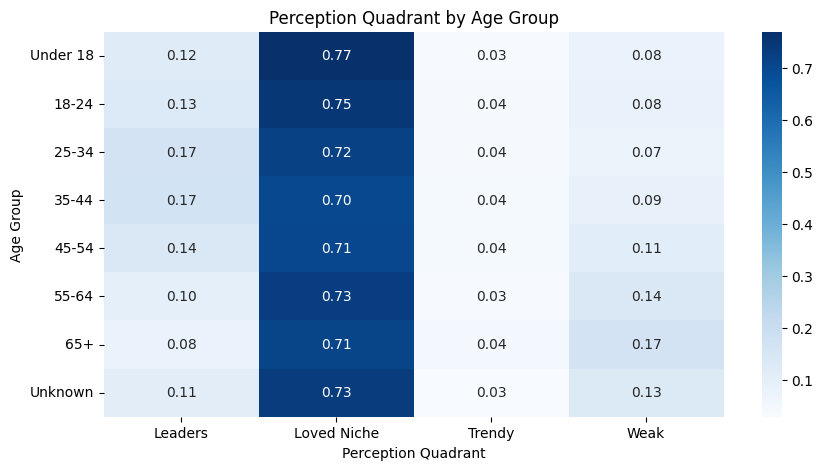

In [30]:
plt.figure(figsize=(10,5))

sns.heatmap(
    ct,
    annot = True,
    cmap = 'Blues',
    fmt = '.2f'
)

plt.title('Perception Quadrant by Age Group')
plt.ylabel('Age Group')
plt.xlabel('Perception Quadrant')
plt.show()

In [31]:
(
    df_analysis[df_analysis['Relation'] == 'WantToWorkWith']
    .groupby('Age_Group')['AlignmentGap']
    .mean()
)

Age_Group
18-24       0.589103
25-34       0.603804
35-44       0.599126
45-54       0.589640
55-64       0.605805
65+         0.575269
Under 18    0.628159
Unknown     0.633803
Name: AlignmentGap, dtype: float64

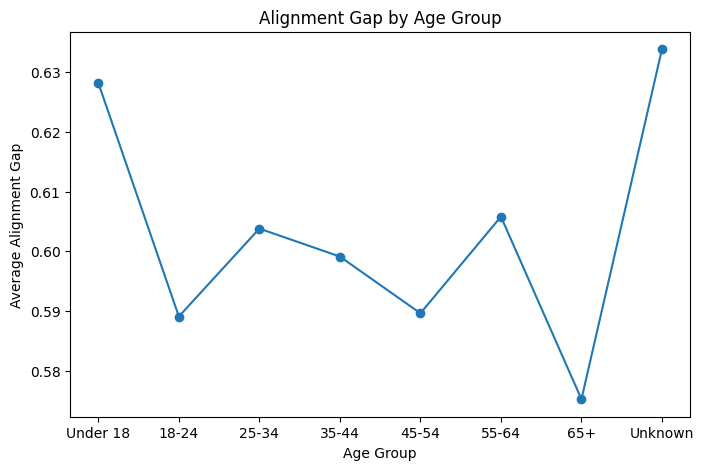

In [32]:
gap_age = (
    df_analysis[df_analysis['Relation'] == 'WantToWorkWith']
    .groupby('Age_Group')['AlignmentGap']
    .mean()
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
gap_age = gap_age.loc[order]

gap_age.plot(
    kind = 'line',
    marker = 'o',
    figsize = (8,5)
)

plt.ylabel('Average Alignment Gap')
plt.xlabel('Age Group')
plt.title('Alignment Gap by Age Group')
plt.show()

- Los desarrolladores tienden a evaluar las tecnologías más positivamente que su posición real en el mercado.
- La brecha entre la percepción y el mercado sigue siendo relativamente constante entre los grupos de edad, lo que sugiere que los desarrolladores de diferentes edades evalúan las tecnologías de manera similar en relación con su adopción en el mercado.
- Los desarrolladores más jóvenes muestran brechas de percepción ligeramente mayores, lo que indica una tendencia a calificar las tecnologías de manera más favorable en relación con su adopción en el mercado.

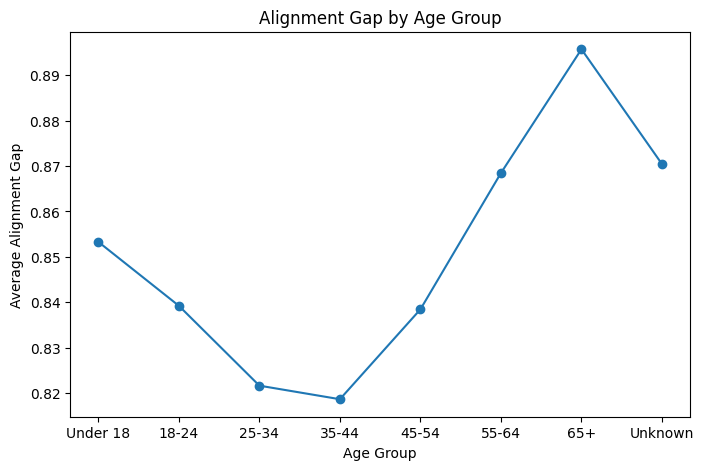

In [33]:
gap_age_mag = (
    df_analysis[df_analysis['Relation'] == 'WantToWorkWith']
    .groupby('Age_Group')['AlignmentGap']
    .apply(lambda x: x.abs().mean())
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
gap_age_mag = gap_age_mag.loc[order]

gap_age_mag.plot(
    kind = 'line',
    marker = 'o',
    figsize = (8,5)
)

plt.ylabel('Average Alignment Gap')
plt.xlabel('Age Group')
plt.title('Alignment Gap by Age Group')
plt.show()